RINGKASAN MATERI SEBELUM UTS
Materi ini mencakup penggunaan `pandas`, `matplotlib`, serta model klasifikasi seperti Naive Bayes dan Decision Tree dengan data siswa.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [2]:
data = {
    'Nama': ['Ayu', 'Budi', 'Citra', 'Dedi', 'Eka', 'Fajar', 'Gina', 'Hadi'],
    'Nilai_Matematika': [78, 85, 60, 90, 70, 88, 55, 92],
    'Nilai_Bahasa': [80, 70, 65, 95, 60, 85, 50, 90],
    'Nilai_Inggris': [75, 72, 62, 96, 58, 87, 53, 93]
}
df = pd.DataFrame(data)
df["Rata_Rata"] = df[['Nilai_Matematika', 'Nilai_Bahasa', 'Nilai_Inggris']].mean(axis=1)
df["Lulus"] = df["Rata_Rata"].apply(lambda x: "Ya" if x >= 70 else "Tidak")
df

,Nama,Nilai_Matematika,Nilai_Bahasa,Nilai_Inggris,Rata_Rata,Lulus
0,Ayu,78,80,75,77.666667,Ya
1,Budi,85,70,72,75.666667,Ya
2,Citra,60,65,62,62.333333,Tidak
3,Dedi,90,95,96,93.666667,Ya
4,Eka,70,60,58,62.666667,Tidak
5,Fajar,88,85,87,86.666667,Ya
6,Gina,55,50,53,52.666667,Tidak
7,Hadi,92,90,93,91.666667,Ya


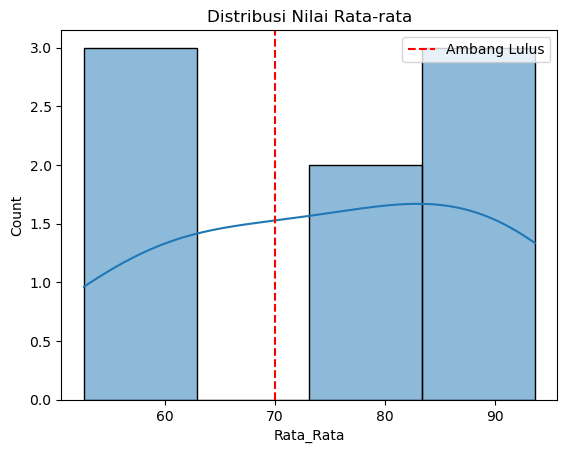

In [3]:
sns.histplot(df["Rata_Rata"], kde=True)
plt.axvline(70, color='red', linestyle='--', label='Ambang Lulus')
plt.title("Distribusi Nilai Rata-rata")
plt.legend()
plt.show()

In [4]:
le = LabelEncoder()
df['Lulus_Label'] = le.fit_transform(df['Lulus'])  # Ya = 1, Tidak = 0

X = df[['Nilai_Matematika', 'Nilai_Bahasa', 'Nilai_Inggris']]
y = df['Lulus_Label']

# Perbaikan: stratify dan test_size lebih besar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

In [5]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



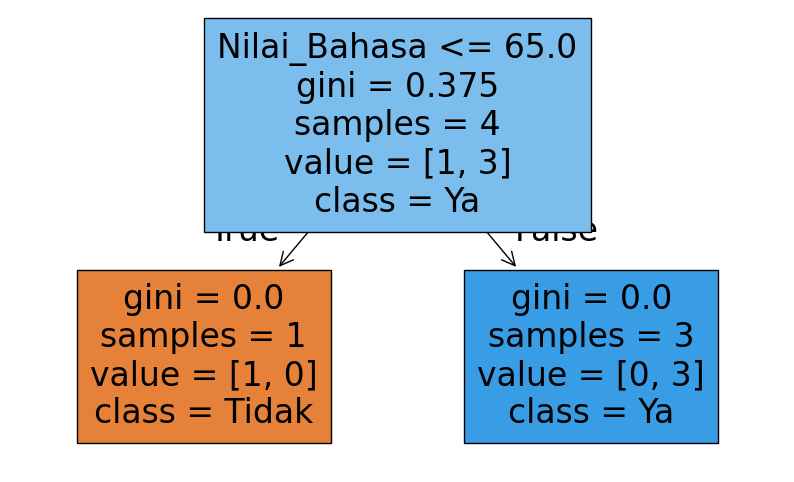

In [6]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

plt.figure(figsize=(10,6))
plot_tree(dt_model, feature_names=X.columns, class_names=["Tidak", "Ya"], filled=True)
plt.show()